# Ejercicio 1

Todo el código reutilizable se importa desde `src/lista4/`.

In [10]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lista4.data import load_csv
from lista4.models import fit_linear
from lista4.metrics import riesgo_cuadratico

ModuleNotFoundError: No module named 'sklearn'

In [2]:
df = load_csv("experimento_1.csv")
x1 = df["x1"].values
x2 = df["x2"].values
y = df["y"].values
X12 = df[["x1", "x2"]].values
df.head()

,x1,x2,y
0,0.304717,1.727350,1.429562
1,-1.039984,-1.533861,-3.697491
2,0.750451,0.863828,3.525801
3,0.940565,-0.328525,2.194107
4,-1.951035,-0.061324,-6.489721


## (a) Tabla con los tres modelos

In [3]:
modelo_x1 = fit_linear(x1, y)
modelo_x2 = fit_linear(x2, y)
modelo_x12 = fit_linear(X12, y)

R_x1 = riesgo_cuadratico(y, modelo_x1.predict(x1.reshape(-1, 1)))
R_x2 = riesgo_cuadratico(y, modelo_x2.predict(x2.reshape(-1, 1)))
R_x12 = riesgo_cuadratico(y, modelo_x12.predict(X12))

tabla_1 = pd.DataFrame({
    "modelo": ["x1 -> y", "x2 -> y", "(x1,x2) -> y"],
    "intercepto": [modelo_x1.intercept_, modelo_x2.intercept_, modelo_x12.intercept_],
    "coef_x1": [modelo_x1.coef_[0], np.nan, modelo_x12.coef_[0]],
    "coef_x2": [np.nan, modelo_x2.coef_[0], modelo_x12.coef_[1]],
    "riesgo_empirico": [R_x1, R_x2, R_x12],
})
tabla_1

,modelo,intercepto,coef_x1,coef_x2,riesgo_empirico
0,x1 -> y,-0.082506,2.92046,NaN,1.020069
1,x2 -> y,-0.202971,NaN,-0.044049,8.374587
2,"(x1,x2) -> y",-0.083790,2.92513,-0.131194,1.002351


## (b) Correlaciones

In [4]:
corr_x1_y = np.corrcoef(x1, y)[0, 1]
corr_x2_y = np.corrcoef(x2, y)[0, 1]
corr_x1_x2 = np.corrcoef(x1, x2)[0, 1]

print("corr(x1, y) =", corr_x1_y)
print("corr(x2, y) =", corr_x2_y)
print("corr(x1, x2) =", corr_x1_x2)

corr(x1, y) = 0.9371359656907724
corr(x2, y) = -0.0154496727944874
corr(x1, x2) = 0.032563224619121305


## (c) Gráficas con la recta ajustada

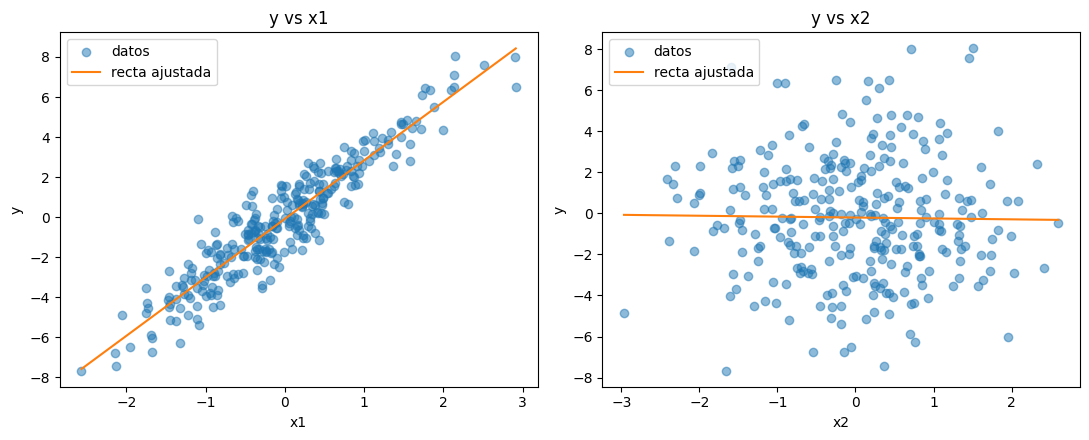

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

orden1 = np.argsort(x1)
axes[0].scatter(x1, y, alpha=0.5, label="datos")
axes[0].plot(x1[orden1], modelo_x1.predict(x1.reshape(-1, 1))[orden1], color="C1", label="recta ajustada")
axes[0].set_xlabel("x1"); axes[0].set_ylabel("y"); axes[0].set_title("y vs x1"); axes[0].legend()

orden2 = np.argsort(x2)
axes[1].scatter(x2, y, alpha=0.5, label="datos")
axes[1].plot(x2[orden2], modelo_x2.predict(x2.reshape(-1, 1))[orden2], color="C1", label="recta ajustada")
axes[1].set_xlabel("x2"); axes[1].set_ylabel("y"); axes[1].set_title("y vs x2"); axes[1].legend()

plt.tight_layout()
plt.show()

## (d) ¿Cuál variable conservar?

In [6]:
mejor = "x1" if R_x1 < R_x2 else "x2"
print(f"R_S(x1->y) = {R_x1:.4f}")
print(f"R_S(x2->y) = {R_x2:.4f}")
print(f"Se conservaría: {mejor} (menor riesgo empirico)")

R_S(x1->y) = 1.0201
R_S(x2->y) = 8.3746
Se conservaría: x1 (menor riesgo empirico)


**Respuesta (d):** se conserva la variable con menor riesgo empírico entre los dos modelos de una sola variable (ver celda anterior para el valor exacto y cuál resultó ganadora).